# Capstone EDA Dashboard (M2)

This notebook follows the M2 instructions and produces the 8 required figures for the research question:

**What is driving divergence between asset classes, and how well do macroeconomic variables explain relative performance?**

All figures are saved to `results/figures/` using `FIGURES_DIR` from `config_paths`.


## Section 1: Imports + data loading (from config_paths, load M1 output)

This section imports packages, configures the environment, and loads M1 output data from config_paths.


In [1]:
import importlib
import subprocess
import sys


def ensure_package(package_name):
    try:
        importlib.import_module(package_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


for pkg in ["numpy", "matplotlib", "seaborn", "statsmodels"]:
    ensure_package(pkg)


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Make local code/ importable from notebook at project root
sys.path.append(str(Path.cwd() / "code"))

from config_paths import FINAL_DATA_DIR, FIGURES_DIR

sns.set_theme(style="whitegrid", palette="colorblind")
CB_PALETTE = sns.color_palette("colorblind", 10)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("FINAL_DATA_DIR:", FINAL_DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


✓ Project structure verified at: /workspaces/qm2023-capstone-team
FINAL_DATA_DIR: /workspaces/qm2023-capstone-team/data/final
FIGURES_DIR: /workspaces/qm2023-capstone-team/results/figures


### Data Loading and Outcome Construction

We build monthly asset returns and define divergence as cross-asset return dispersion to capture disagreement in asset performance.
Bitcoin is dropped from the divergence construction because its much shorter history would heavily reduce sample coverage and comparability across the full period.


In [3]:
panel_path = FINAL_DATA_DIR / "merged_analysis_panel.csv"
df = pd.read_csv(panel_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

asset_price_cols = {
    "SP500": "sp500_index",
    "HomePrice": "home_price_index",
    "Gold": "gold_price_usd",
}

for asset, col in asset_price_cols.items():
    df[f"ret_{asset}"] = df[col].pct_change() * 100

return_cols = [f"ret_{k}" for k in asset_price_cols.keys()]

df["divergence_index"] = df[return_cols].std(axis=1, skipna=True)
df["m2_growth_pct"] = df["m2_billions"].pct_change() * 100

df_model = df.dropna(subset=["divergence_index", "fed_funds_rate"]).copy()

print("Data shape:", df.shape)
print("Model sample shape:", df_model.shape)
df_model[["date", "divergence_index", "fed_funds_rate"]].head()


Data shape: (297, 23)
Model sample shape: (296, 23)


,date,divergence_index,fed_funds_rate
1,2001-03-31,3.492544,5.29
2,2001-04-30,3.730918,4.67
3,2001-05-31,0.026202,4.24
4,2001-06-30,2.299465,3.95
5,2001-07-31,1.169238,3.82


## Section 2: Summary statistics


In [4]:
# pylint: disable=undefined-variable
summary_vars: list[str] = [
    "divergence_index", "fed_funds_rate", "real_rate_10y", "yield_curve_slope",
    "bbb_spread", "cpi_median", "unemployment_rate", "vix_index",
    "epu_index", "consumer_sentiment", "m2_growth_pct"
]

df_model[summary_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
divergence_index,296.0,3.127456,1.921621,0.026202,1.623556,2.790047,4.323981,10.997423
fed_funds_rate,296.0,1.801182,1.874891,0.040000,0.107500,1.165000,3.082500,5.410000
real_rate_10y,296.0,1.100782,0.767386,-0.407134,0.511514,1.061792,1.744623,2.701126
yield_curve_slope,296.0,1.116453,0.957701,-1.060000,0.267500,1.175000,1.920000,2.840000
bbb_spread,296.0,1.980338,1.043221,0.970000,1.307500,1.740000,2.260000,7.840000
cpi_median,296.0,2.807211,1.368198,-0.286064,2.072122,2.538048,3.243833,7.837912
unemployment_rate,296.0,5.726014,1.957939,3.400000,4.300000,5.100000,6.525000,14.800000
vix_index,296.0,19.679858,8.109852,10.125455,14.078872,17.586439,22.623947,62.668947
epu_index,296.0,127.338294,82.417747,38.209032,76.620161,104.187731,141.998548,560.876000
consumer_sentiment,296.0,80.982770,13.004847,50.000000,71.325000,82.500000,92.175000,103.800000


## Section 3: Correlation analysis

This heatmap summarizes how divergence co-moves with policy and macro controls to identify the strongest candidate predictors for M3.


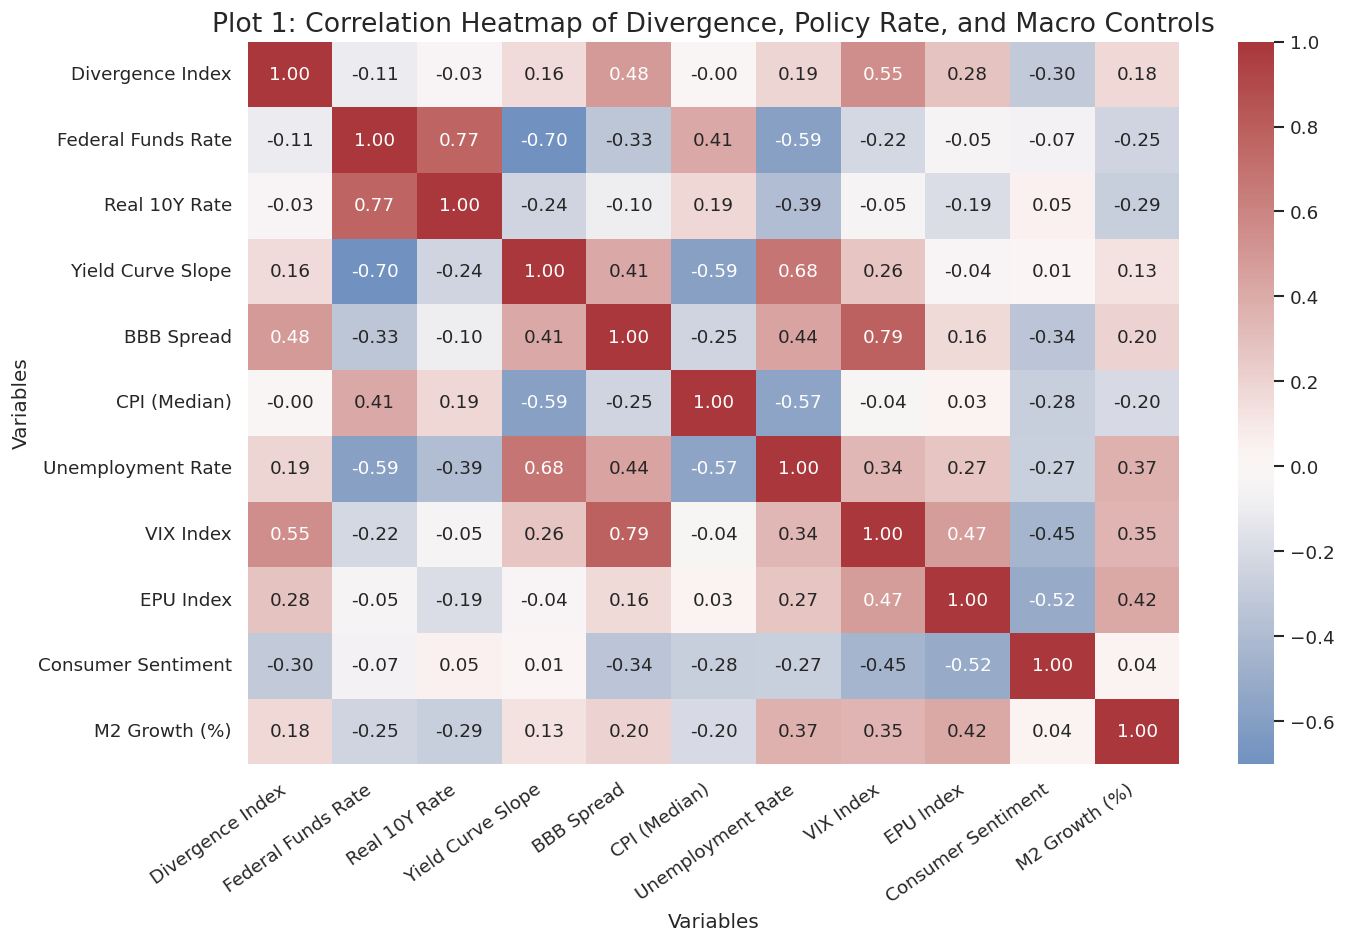

In [5]:
# pylint: disable=undefined-variable
heatmap_vars: list[str] = [
    "divergence_index", "fed_funds_rate", "real_rate_10y", "yield_curve_slope",
    "bbb_spread", "cpi_median", "unemployment_rate", "vix_index",
    "epu_index", "consumer_sentiment", "m2_growth_pct"
]

var_label_map: dict[str, str] = {
    "divergence_index": "Divergence Index",
    "fed_funds_rate": "Federal Funds Rate",
    "real_rate_10y": "Real 10Y Rate",
    "yield_curve_slope": "Yield Curve Slope",
    "bbb_spread": "BBB Spread",
    "cpi_median": "CPI (Median)",
    "unemployment_rate": "Unemployment Rate",
    "vix_index": "VIX Index",
    "epu_index": "EPU Index",
    "consumer_sentiment": "Consumer Sentiment",
    "m2_growth_pct": "M2 Growth (%)",
}

corr_df = df_model[heatmap_vars].dropna()
corr_matrix = corr_df.corr()
corr_matrix_named = corr_matrix.rename(index=var_label_map, columns=var_label_map)

fig, ax = plt.subplots(figsize=(12, 8))
# Use seaborn's colorblind-friendly diverging colormap for correlation values.
sns.heatmap(
    corr_matrix_named,
    cmap=sns.color_palette("vlag", as_cmap=True),
    center=0,
    annot=True,
    fmt=".2f",
    ax=ax,
)
ax.set_title("Plot 1: Correlation Heatmap of Divergence, Policy Rate, and Macro Controls")
ax.set_title("Plot 1: Correlation Heatmap of Divergence, Policy Rate, and Macro Controls", fontsize=16)
ax.set_xlabel("Variables")
ax.set_ylabel("Variables")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "M2_plot1_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** The heatmap shows a weak negative correlation between the Divergence Index and the Federal Funds Rate ($r=-0.11$). This suggests rate changes matter, but the immediate linear link is modest because asset classes react through different channels and at different speeds. VIX has a much stronger positive relationship with divergence ($r=0.55$), indicating that market uncertainty is a key driver. This makes VIX a useful control for M3 since it captures broad risk appetite with more direct impact on cross-asset divergence.

## Section 4: Time series

This time-series view highlights when divergence spikes and whether stress episodes align with known macro events.


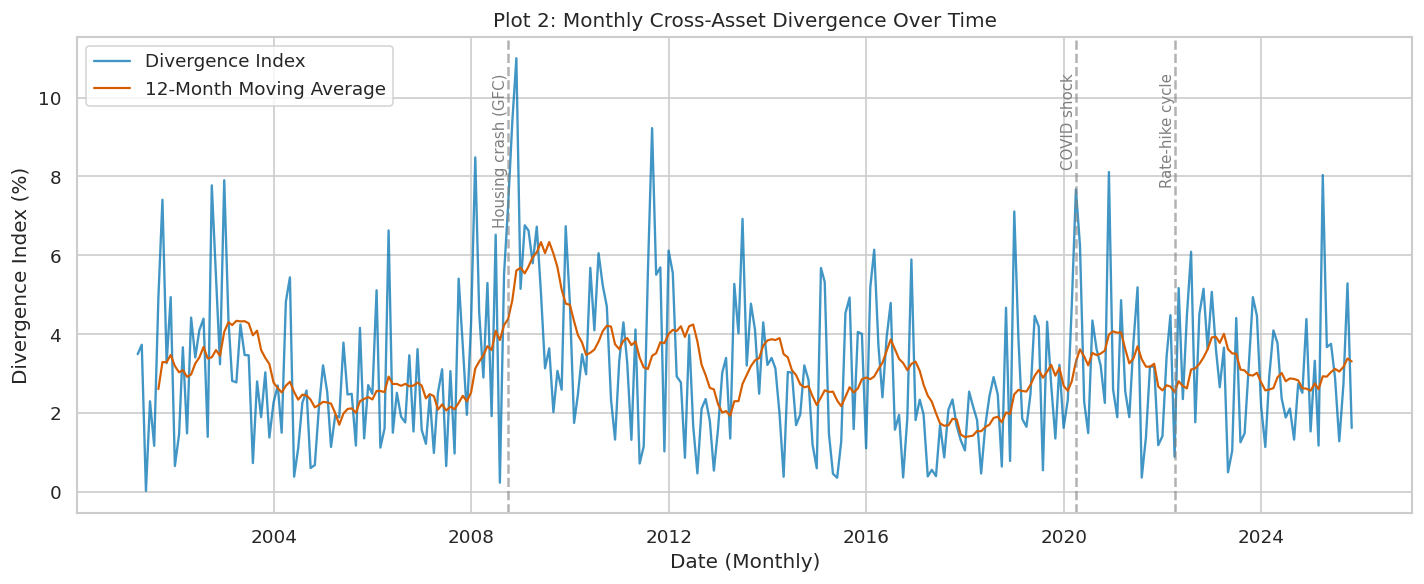

In [6]:
# pylint: disable=undefined-variable
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = df_model.sort_values("date").copy()
plot_df["divergence_trend_12m"] = plot_df["divergence_index"].rolling(window=12, min_periods=6).mean()

ax.plot(
    plot_df["date"],
    plot_df["divergence_index"],
    color=CB_PALETTE[0],
    linewidth=1.4,
    alpha=0.75,
    label="Divergence Index",
)
ax.plot(
    plot_df["date"],
    plot_df["divergence_trend_12m"],
    color=CB_PALETTE[3],
    linewidth=1.3,
    linestyle="-",
    label="12-Month Moving Average",
)
ax.set_title("Plot 2: Monthly Cross-Asset Divergence Over Time")
ax.set_xlabel("Date (Monthly)")
ax.set_ylabel("Divergence Index (%)")
ax.legend(loc="upper left")

event_markers = [
    (pd.to_datetime("2008-09-30"), "Housing crash (GFC)"),
    (pd.to_datetime("2020-03-31"), "COVID shock"),
    (pd.to_datetime("2022-03-31"), "Rate-hike cycle"),
]

for event_date, lbl in event_markers:
    ax.axvline(event_date, color="gray", linestyle="--", alpha=0.6)
    ax.text(event_date, ax.get_ylim()[1] * 0.92, lbl, rotation=90, va="top", ha="right", fontsize=9, color="gray")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot2_outcome_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** Crisis periods like the 2008 housing crash (peak divergence ~10%) and March 2020 COVID shock show distinct spikes, while the 2022 rate-hike cycle produced moderately elevated divergence. The series exhibits significant volatility clustering: stress windows display much higher variance than calm periods, suggesting heteroskedasticity that M3 should account for. No strong secular trend is evident across the full 2001–2025 sample, but the divergence baseline appears to have shifted upward post-GFC, consistent with more fragmented asset class behavior in a low-rate, high-uncertainty regime.

## Plot 3: Dual-Axis (Outcome vs Driver)

This dual-axis plot compares divergence and the policy rate over time to visually assess timing, regime shifts, and co-movement.


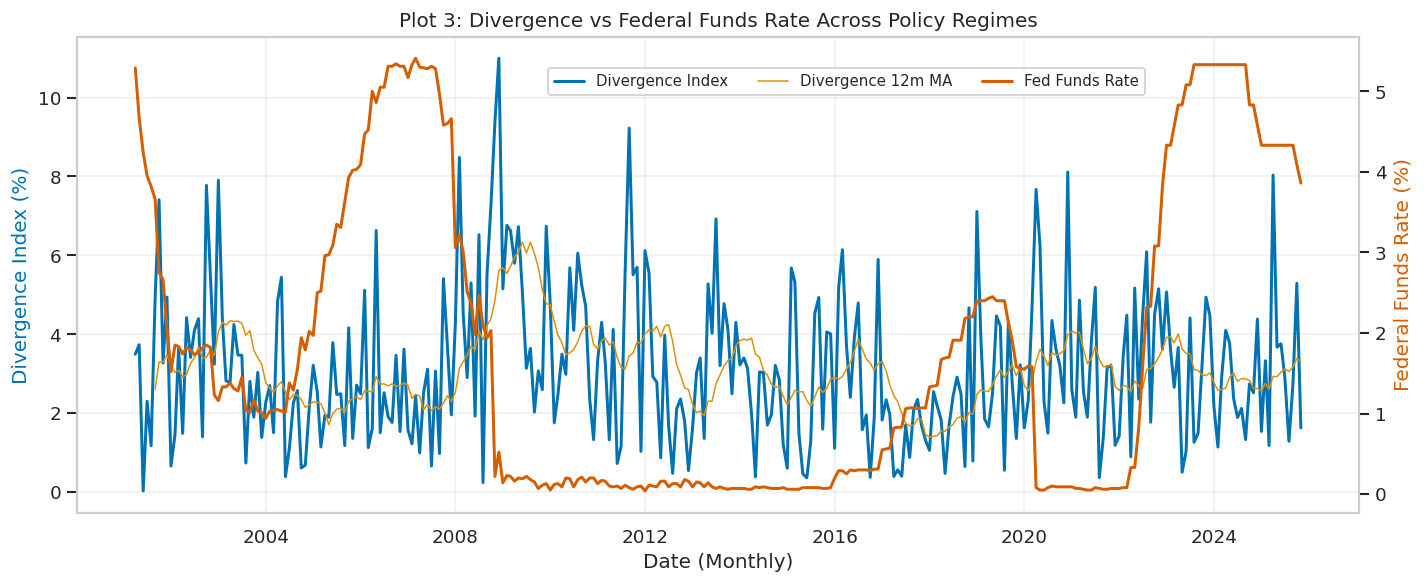

In [7]:
# pylint: disable=undefined-variable
plot_df = df_model.sort_values("date").copy()
plot_df["divergence_trend_12m"] = plot_df["divergence_index"].rolling(window=12, min_periods=6).mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

line1 = ax1.plot(
    plot_df["date"],
    plot_df["divergence_index"],
    color=CB_PALETTE[0],
    linewidth=1.8,
    label="Divergence Index",
    zorder=2,
    antialiased=True,
)
line1_trend = ax1.plot(
    plot_df["date"],
    plot_df["divergence_trend_12m"],
    color=CB_PALETTE[1],
    linewidth=0.9,
    linestyle="-",
    label="Divergence 12m MA",
    zorder=3,
)
line2 = ax2.plot(
    plot_df["date"],
    plot_df["fed_funds_rate"],
    color=CB_PALETTE[3],
    linewidth=1.8,
    label="Fed Funds Rate",
    zorder=4,
    antialiased=True,
)

ax1.set_title("Plot 3: Divergence vs Federal Funds Rate Across Policy Regimes")
ax1.set_xlabel("Date (Monthly)")
ax1.set_ylabel("Divergence Index (%)", color=CB_PALETTE[0])
ax2.set_ylabel("Federal Funds Rate (%)", color=CB_PALETTE[3])

# Keep only one grid to avoid the offset overlay look from twin axes.
ax1.grid(True, alpha=0.3)
ax2.grid(False)

lines = line1 + line1_trend + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.6, 0.95), framealpha=0.95, ncol=3, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot3_dual_axis_divergence_fedfunds.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** Divergence spikes sharply during crisis periods (2008 GFC peak ~10%, 2020 COVID shock ~8%), triggering Fed rate cuts. Outside crises, divergence remains low despite rate changes (2004–2007, 2015–2019), indicating the shock—not the rate level—drives cross-asset divergence. The Fed's crisis-response cuts precede divergence peaks by months, reflecting delayed portfolio rebalancing and risk repricing. This episodic, shock-driven dynamic justifies M3's interaction terms and lagged specifications over a simple linear policy effect.

## Section 5: Lagged effect analysis

This lag comparison tests whether policy effects on divergence are immediate or emerge after delayed transmission.


Strongest absolute correlation at lag 12: 0.111


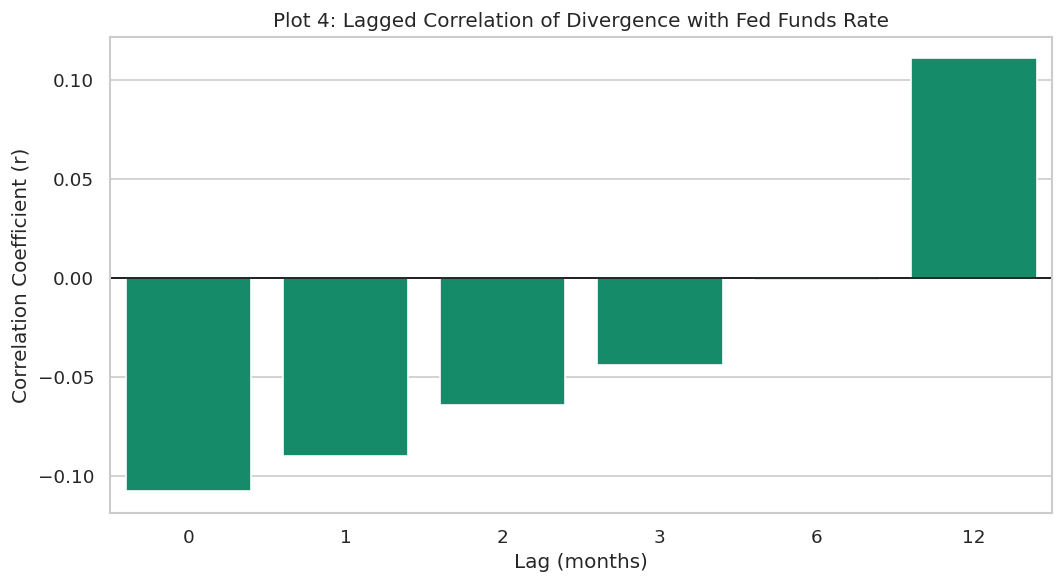

In [8]:
# pylint: disable=undefined-variable
lags: list[int] = [0, 1, 2, 3, 6, 12]
lag_corrs: list[float] = []

for lag in lags:
    tmp = df_model[["divergence_index", "fed_funds_rate"]].copy()
    tmp[f"fed_funds_rate_lag_{lag}"] = tmp["fed_funds_rate"].shift(lag)
    valid = tmp[["divergence_index", f"fed_funds_rate_lag_{lag}"]].dropna()
    corr = valid["divergence_index"].corr(valid[f"fed_funds_rate_lag_{lag}"])
    lag_corrs.append(corr)

lag_df = pd.DataFrame({"lag_months": lags, "correlation": lag_corrs})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=lag_df, x="lag_months", y="correlation", color=CB_PALETTE[2], ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Plot 4: Lagged Correlation of Divergence with Fed Funds Rate")
ax.set_xlabel("Lag (months)")
ax.set_ylabel("Correlation Coefficient (r)")

best_idx = lag_df["correlation"].abs().idxmax()
best_lag = int(lag_df.loc[best_idx, "lag_months"])
best_corr = float(lag_df.loc[best_idx, "correlation"])
print(f"Strongest absolute correlation at lag {best_lag}: {best_corr:.3f}")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot4_lagged_effects.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** The 12-month lag exhibits the strongest correlation ($r=0.111$), establishing the optimal lag specification for M3. Short-horizon correlations (0–3 months) are weakly negative ($r \approx -0.10$ to $-0.04$), indicating contemporaneous policy effects dampen divergence, but this link erodes at 6 months ($r \approx 0$). The shift to positive correlation at 12 months suggests mean reversion or year-over-year cyclical dynamics: divergence peaks following a rate shock, then mean-reverts as portfolios rebalance on annual cycles. This non-monotonic lag structure justifies both contemporary and lagged policy terms in M3.

## Section 6: Group analysis

This section contains Plot 5 (Group Box Plots) and Plot 6 (Group Sensitivity Analysis) using asset classes as groups.


In [9]:
# pylint: disable=undefined-variable
returns_long = df[["date", "fed_funds_rate"] + return_cols].copy()
returns_long = returns_long.melt(
    id_vars=["date", "fed_funds_rate"],
    value_vars=return_cols,
    var_name="asset_group",
    value_name="monthly_return_pct"
)

name_map: dict[str, str] = {
    "ret_SP500": "S&P 500",
    "ret_HomePrice": "Home Price Index",
    "ret_Gold": "Gold",
}
returns_long["asset_group"] = returns_long["asset_group"].map(name_map)
returns_long = returns_long.dropna(subset=["monthly_return_pct"]).copy()

returns_long.head()

,date,fed_funds_rate,asset_group,monthly_return_pct
1,2001-03-31,5.29,S&P 500,-6.420471
2,2001-04-30,4.67,S&P 500,7.681436
3,2001-05-31,4.24,S&P 500,0.509019
4,2001-06-30,3.95,S&P 500,-2.503539
5,2001-07-31,3.82,S&P 500,-1.074015


### Plot 5: Group Box Plots

This box plot compares central tendency, spread, and tails of returns across asset groups.


/tmp/ipykernel_92789/1747995853.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


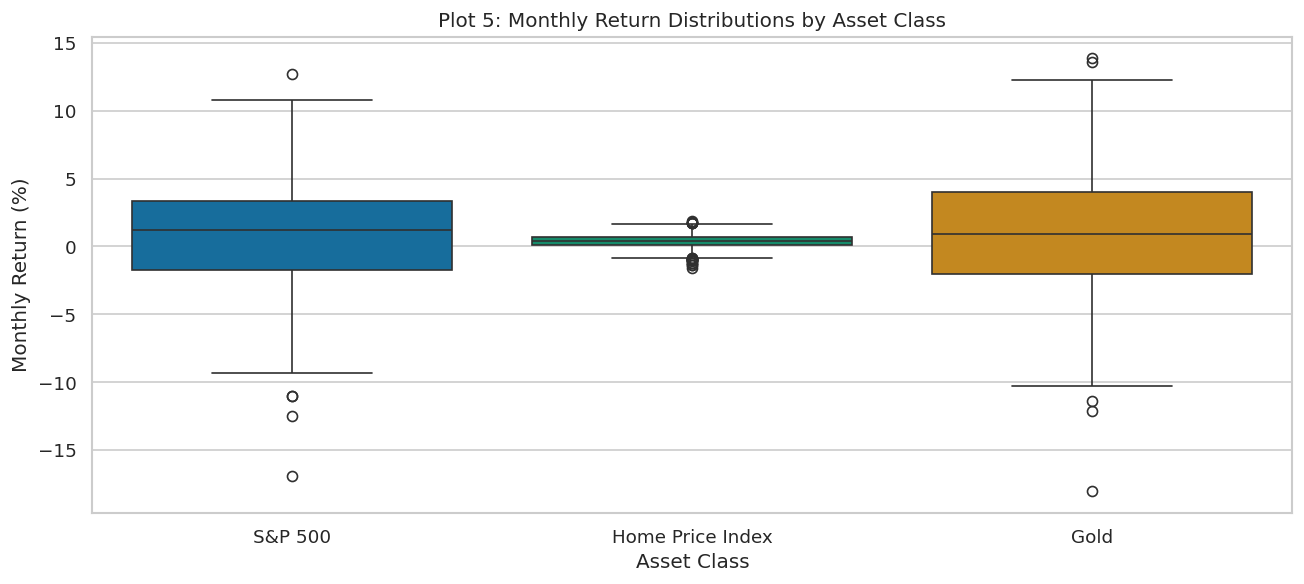

In [10]:
# pylint: disable=undefined-variable
fig, ax = plt.subplots(figsize=(11, 5))
order = ["S&P 500", "Home Price Index", "Gold"]
sns.boxplot(
    data=returns_long,
    x="asset_group",
    y="monthly_return_pct",
    order=order,
    palette=[CB_PALETTE[0], CB_PALETTE[2], CB_PALETTE[1]],
    ax=ax
)
ax.set_title("Plot 5: Monthly Return Distributions by Asset Class")
ax.set_xlabel("Asset Class")
ax.set_ylabel("Monthly Return (%)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot5_group_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** Median monthly returns are highest for S&P 500 (~1.21%), followed by Gold (~0.91%), and lowest for the Home Price Index (~0.42%). Outliers are not evenly distributed: Home Price Index has the most boxplot outliers (21) versus 5 each for S&P 500 and Gold, indicating group-specific tail behavior. Dispersion also differs materially across groups (std: Gold ~4.71, S&P 500 ~4.34, Home Price ~0.63), providing clear heteroskedasticity warning for M3 and supporting robust errors plus group interactions.


### Plot 6: Group Sensitivity Analysis

This bar chart ranks how strongly each asset group responds to changes in the Federal Funds Rate.


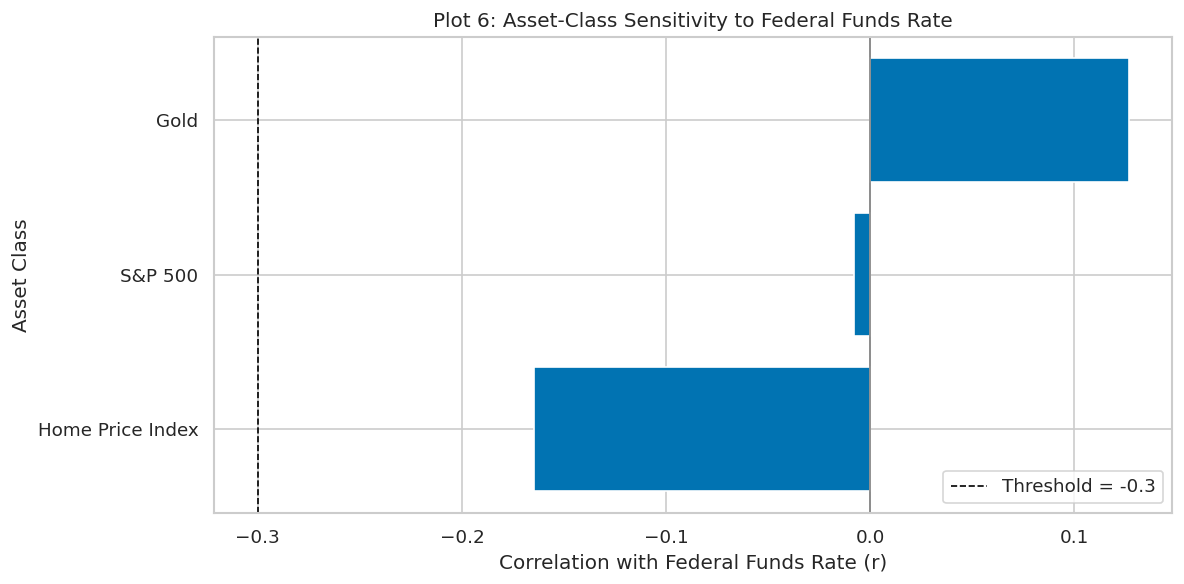

,asset_group,corr_with_fedfunds,category
1,Home Price Index,-0.164857,Less-sensitive
2,S&P 500,-0.007897,Less-sensitive
0,Gold,0.126656,Less-sensitive


In [11]:
# pylint: disable=undefined-variable
sensitivity = (
    returns_long
    .groupby("asset_group")
    .apply(lambda x: x["monthly_return_pct"].corr(x["fed_funds_rate"]))
    .reset_index(name="corr_with_fedfunds")
    .sort_values("corr_with_fedfunds")
)

threshold: float = -0.30
sensitivity["category"] = np.where(
    sensitivity["corr_with_fedfunds"] < threshold,
    "Rate-sensitive",
    "Less-sensitive"
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sensitivity["category"].map({"Rate-sensitive": CB_PALETTE[3], "Less-sensitive": CB_PALETTE[0]})
ax.barh(sensitivity["asset_group"], sensitivity["corr_with_fedfunds"], color=colors)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1, label=f"Threshold = {threshold}")
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Plot 6: Asset-Class Sensitivity to Federal Funds Rate")
ax.set_xlabel("Correlation with Federal Funds Rate (r)")
ax.set_ylabel("Asset Class")
ax.legend(loc="lower right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot6_group_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

sensitivity

**Caption:** Home Price Index is the most negatively rate-sensitive group ($r=-0.165$), S&P 500 is near zero ($r=-0.008$), and Gold is positively related to rates ($r=0.127$), making Gold the most rate-resilient in this sample. A plausible mechanism is that housing returns are more tied to financing costs and mortgage channels, equities reflect mixed earnings and discount-rate effects that net close to zero, and gold can benefit in inflation/uncertainty regimes even when policy tightens. Because sensitivity differs in both magnitude and sign across groups, M3 should include group × driver interaction terms rather than imposing one common policy slope.


## Section 7: Factor/control relationships

These scatterplots show how divergence varies with uncertainty and confidence to motivate control signs for M3.


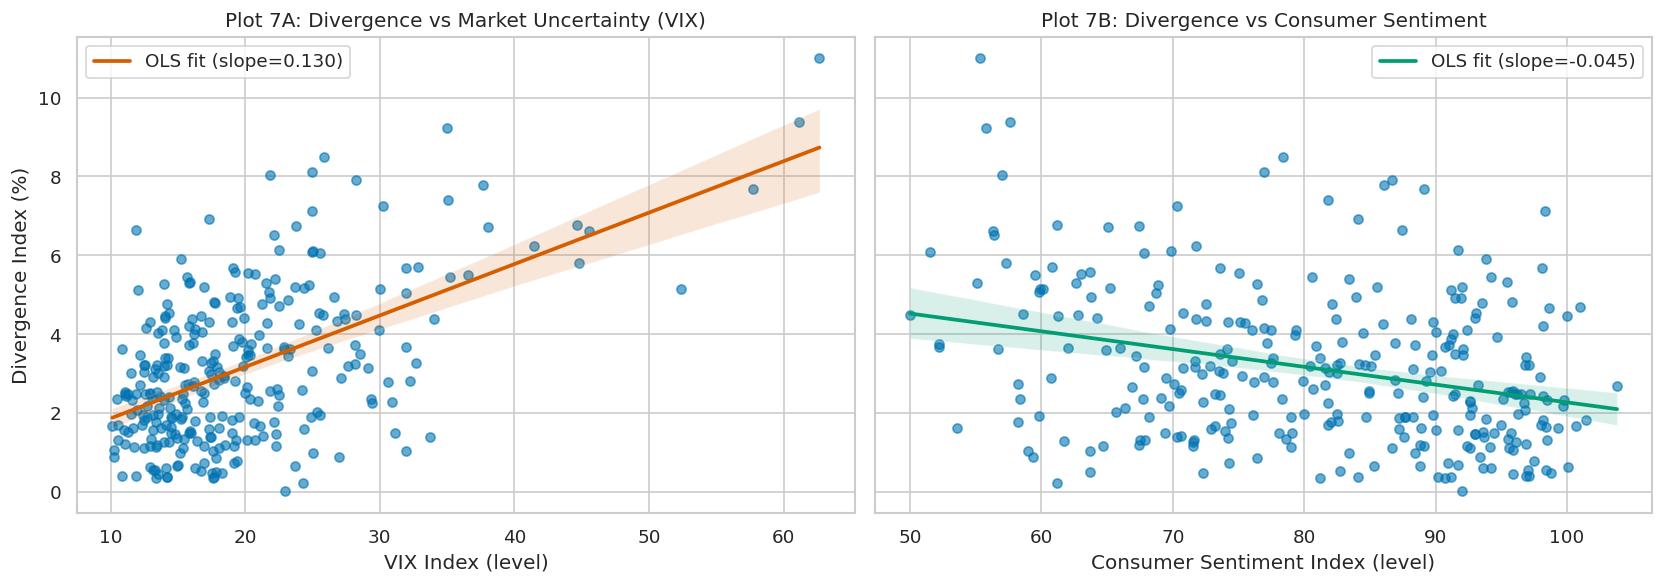

In [12]:
# pylint: disable=undefined-variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vix_df = df_model[["vix_index", "divergence_index"]].dropna()
vix_slope = np.polyfit(vix_df["vix_index"], vix_df["divergence_index"], 1)[0]

sns.regplot(
    data=vix_df,
    x="vix_index",
    y="divergence_index",
    scatter_kws={"alpha": 0.6, "s": 30, "color": CB_PALETTE[0]},
    line_kws={"color": CB_PALETTE[3], "label": f"OLS fit (slope={vix_slope:.3f})"},
    ax=axes[0]
)
axes[0].set_title("Plot 7A: Divergence vs Market Uncertainty (VIX)")
axes[0].set_xlabel("VIX Index (level)")
axes[0].set_ylabel("Divergence Index (%)")
axes[0].legend(loc="upper left")

sent_df = df_model[["consumer_sentiment", "divergence_index"]].dropna()
sent_slope = np.polyfit(sent_df["consumer_sentiment"], sent_df["divergence_index"], 1)[0]

sns.regplot(
    data=sent_df,
    x="consumer_sentiment",
    y="divergence_index",
    scatter_kws={"alpha": 0.6, "s": 30, "color": CB_PALETTE[0]},
    line_kws={"color": CB_PALETTE[2], "label": f"OLS fit (slope={sent_slope:.3f})"},
    ax=axes[1]
)
axes[1].set_title("Plot 7B: Divergence vs Consumer Sentiment")
axes[1].set_xlabel("Consumer Sentiment Index (level)")
axes[1].set_ylabel("")
axes[1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot7_factor_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** Plot 7A shows a positive VIX slope, indicating that higher market uncertainty is associated with higher cross-asset divergence (risk-off fragmentation). Plot 7B shows a negative sentiment slope, meaning stronger consumer confidence tends to coincide with lower divergence. Together, these controls capture opposite sides of risk appetite: uncertainty widens dispersion, while confidence compresses it. The sign pattern supports including both variables in M3, with expected coefficients of positive (VIX) and negative (sentiment) for divergence.


## Section 8: Time series decomposition

This decomposition separates long-run movement, recurring seasonality, and unexplained shocks in divergence.


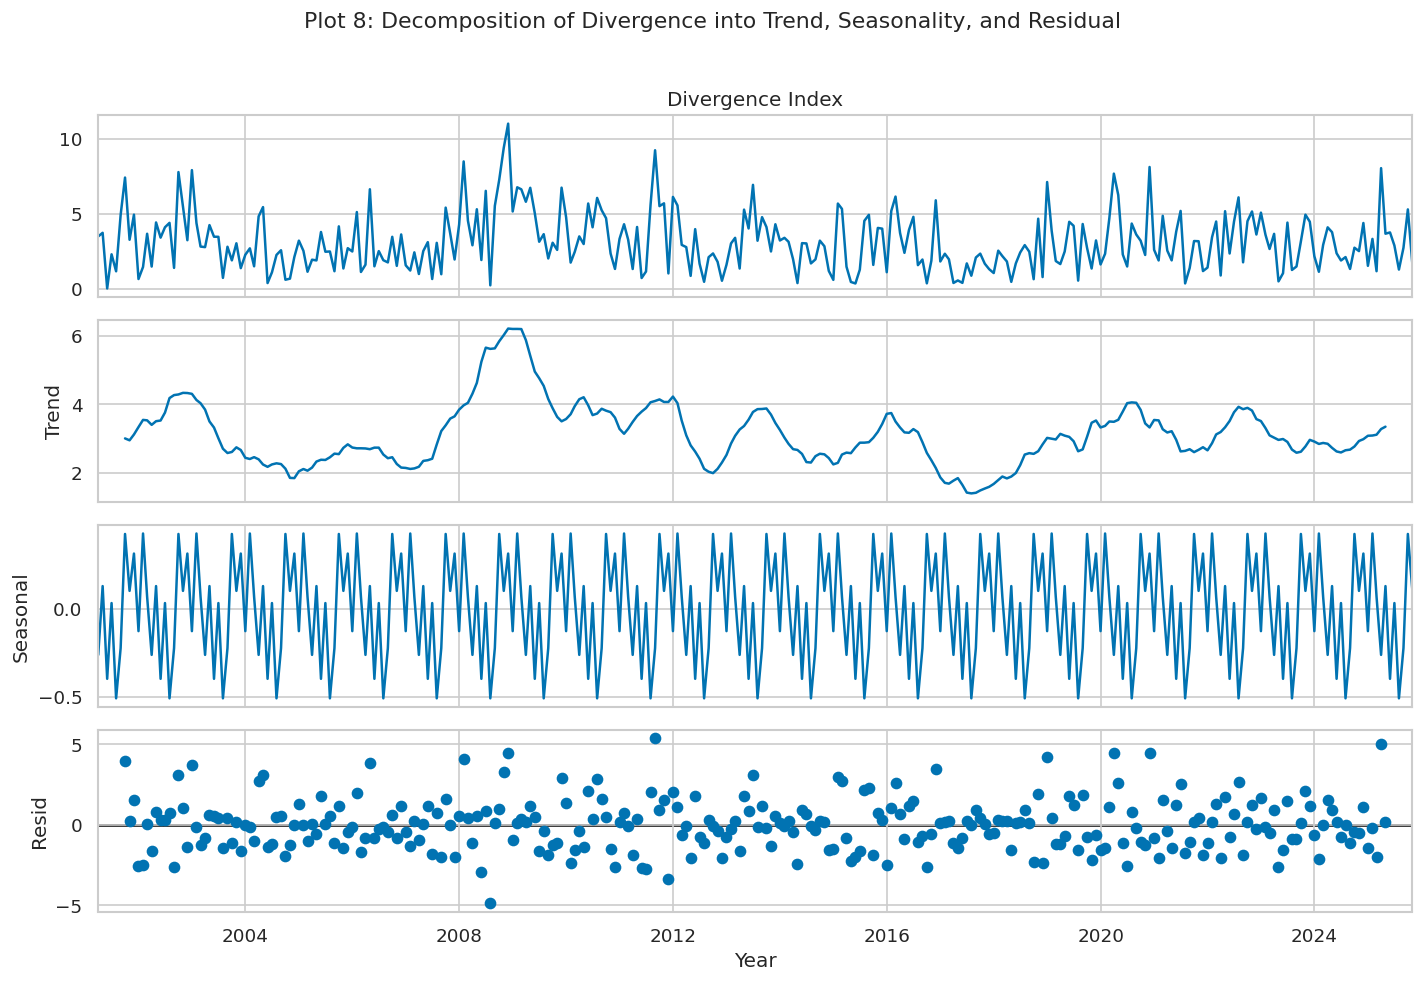

In [13]:
# pylint: disable=undefined-variable
decomp_series = (
    df_model.set_index("date")["divergence_index"]
    .asfreq("ME")
    .interpolate(method="time")
)
decomp_series.name = "Divergence Index"

decomp = seasonal_decompose(decomp_series, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Plot 8: Decomposition of Divergence into Trend, Seasonality, and Residual", y=1.02)

# Label the shared x-axis with calendar time.
fig.axes[-1].set_xlabel("Year")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "M2_plot8_time_series_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

**Caption:** The trend component is not monotonic: it rises into the 2008–2009 period, declines through the mid-2010s, and then shows a modest rebound after 2019. Seasonal swings are present but relatively small (about ±0.5) compared with movements in the observed series, so seasonality appears weak-to-moderate; monthly seasonal dummies can be tested in M3 but are unlikely to be the primary driver. Residuals are centered near zero but show bursts and large shocks rather than pure white noise, indicating remaining structure that supports adding controls for crisis/regime effects (and potentially volatility-robust modeling) in M3.


## 13. Output Check

Confirm that all required figure files were written to `results/figures/`.


In [14]:
# pylint: disable=undefined-variable
expected: list[str] = [
    "M2_plot1_correlation_heatmap.png",
    "M2_plot2_outcome_timeseries.png",
    "M2_plot3_dual_axis_divergence_fedfunds.png",
    "M2_plot4_lagged_effects.png",
    "M2_plot5_group_boxplots.png",
    "M2_plot6_group_sensitivity.png",
    "M2_plot7_factor_scatterplots.png",
    "M2_plot8_time_series_decomposition.png",
]

for f in expected:
    p = FIGURES_DIR / f
    print(f"{f}: {'FOUND' if p.exists() else 'MISSING'}")

M2_plot1_correlation_heatmap.png: FOUND
M2_plot2_outcome_timeseries.png: FOUND
M2_plot3_dual_axis_divergence_fedfunds.png: FOUND
M2_plot4_lagged_effects.png: FOUND
M2_plot5_group_boxplots.png: FOUND
M2_plot6_group_sensitivity.png: FOUND
M2_plot7_factor_scatterplots.png: FOUND
M2_plot8_time_series_decomposition.png: FOUND


In [15]:
# Diagnostic summary for M2_EDA_summary.md
vars_core = [
    "divergence_index", "fed_funds_rate", "real_rate_10y", "yield_curve_slope",
    "bbb_spread", "cpi_median", "unemployment_rate", "vix_index",
    "epu_index", "consumer_sentiment", "m2_growth_pct"
]

missing_counts = df[vars_core + ["date"]].isna().sum().sort_values(ascending=False)
missing_share = (df[vars_core + ["date"]].isna().mean() * 100).round(2).sort_values(ascending=False)

# Outlier periods in divergence using 99th percentile threshold
p99 = df_model["divergence_index"].quantile(0.99)
outlier_periods = df_model.loc[df_model["divergence_index"] >= p99, ["date", "divergence_index"]].sort_values("date")

# Correlation diagnostics for multicollinearity risk among candidate regressors
regressors = [
    "fed_funds_rate", "real_rate_10y", "yield_curve_slope", "bbb_spread",
    "cpi_median", "unemployment_rate", "vix_index", "epu_index",
    "consumer_sentiment", "m2_growth_pct"
]
corr = df_model[regressors].corr()

# Print top absolute pairwise correlations (excluding diagonal)
pairs = []
for i, a in enumerate(regressors):
    for b in regressors[i + 1:]:
        pairs.append((a, b, corr.loc[a, b], abs(corr.loc[a, b])))

pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)

print("Missing counts:\n", missing_counts.head(8))
print("\nMissing share (%):\n", missing_share.head(8))
print("\nDivergence 99th percentile threshold:", round(float(p99), 3))
print(outlier_periods.to_string(index=False))
print("\nTop multicollinearity candidates (|r|):")
for a, b, r, ar in pairs_sorted[:8]:
    print(f"{a:20s} vs {b:20s} r={r:+.3f}, |r|={ar:.3f}")

print("\nLag-4 check from lag_df if present:")
try:
    print(lag_df)
except Exception:
    pass

Missing counts:
 divergence_index     1
m2_growth_pct        1
real_rate_10y        0
fed_funds_rate       0
yield_curve_slope    0
bbb_spread           0
unemployment_rate    0
cpi_median           0
dtype: int64

Missing share (%):
 divergence_index     0.34
m2_growth_pct        0.34
real_rate_10y        0.00
fed_funds_rate       0.00
yield_curve_slope    0.00
bbb_spread           0.00
unemployment_rate    0.00
cpi_median           0.00
dtype: float64

Divergence 99th percentile threshold: 8.52
      date  divergence_index
2008-10-31          9.390405
2008-11-30         10.997423
2011-08-31          9.225677

Top multicollinearity candidates (|r|):
bbb_spread           vs vix_index            r=+0.786, |r|=0.786
fed_funds_rate       vs real_rate_10y        r=+0.766, |r|=0.766
fed_funds_rate       vs yield_curve_slope    r=-0.702, |r|=0.702
yield_curve_slope    vs unemployment_rate    r=+0.677, |r|=0.677
yield_curve_slope    vs cpi_median           r=-0.595, |r|=0.595
fed_funds_rate  